# Python Exercises - Pandas

## Problem 1


Imagine three people, e.g. family, friends, cohort.

Create a pandas data frame called `cities_df` that contains the following columns:

* Cities - At least 5 cities in the US
* States - The states that those cities reside in
* Region - The region that those cities reside in (NW, SW, Midwest, etc.)
* Times_1 - The number of times person 1 has been to each city
* Times_2 - The number of times person 2 has been to each city
* Times_3 - The number of times person 3 has been to each city


In [4]:
import pandas as pd

In [7]:
cities_df = {
    'Cities' : ['Chicago','Denver','New York City','Los Angeles','Seattle'],
    'States' : ['Illinois','Colorado','New York','California','Washington'],
    'Region' : ['Midwest','West','Northwest','West','West'],
    'Times_1': [5, 2, 1, 0, 3],
    'Times_2': [2, 4, 3, 2, 1],
    'Times_3': [3, 1, 2, 5, 4],
}

cities_df = pd.DataFrame(cities_df)
display(cities_df)

,Cities,States,Region,Times_1,Times_2,Times_3
0,Chicago,Illinois,Midwest,5,2,3
1,Denver,Colorado,West,2,4,1
2,New York City,New York,Northwest,1,3,2
3,Los Angeles,California,West,0,2,5
4,Seattle,Washington,West,3,1,4


## Problem 2


Use the `.describe()` and `.info()` methods on your data frame


In [9]:
cities_df.describe()

,Times_1,Times_2,Times_3
count,5.000000,5.000000,5.000000
mean,2.200000,2.400000,3.000000
std,1.923538,1.140175,1.581139
min,0.000000,1.000000,1.000000
25%,1.000000,2.000000,2.000000
50%,2.000000,2.000000,3.000000
75%,3.000000,3.000000,4.000000
max,5.000000,4.000000,5.000000


In [10]:
cities_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Cities   5 non-null      object
 1   States   5 non-null      object
 2   Region   5 non-null      object
 3   Times_1  5 non-null      int64 
 4   Times_2  5 non-null      int64 
 5   Times_3  5 non-null      int64 
dtypes: int64(3), object(3)
memory usage: 372.0+ bytes


## Problem 3


Use indexing to access the Cities column

In [11]:
cities_col = cities_df['Cities']
cities_col.head()

,Cities
0,Chicago
1,Denver
2,New York City
3,Los Angeles
4,Seattle


## Problem 4


Create a new column called `Total_Times` that contains the total number of times all team members have been to each city.

In [12]:
cities_df['Total_Times'] = cities_df['Times_1'] + cities_df['Times_2'] + cities_df['Times_3']
cities_df

,Cities,States,Region,Times_1,Times_2,Times_3,Total_Times
0,Chicago,Illinois,Midwest,5,2,3,10
1,Denver,Colorado,West,2,4,1,7
2,New York City,New York,Northwest,1,3,2,6
3,Los Angeles,California,West,0,2,5,7
4,Seattle,Washington,West,3,1,4,8


## Problem 5


[link text](https://)Use indexing to access the cities that have been travelled to more than two times.

In [22]:
filter = (cities_df['Times_1'] > 2)
cities_df[filter]

,Cities,States,Region,Times_1,Times_2,Times_3,Total_Times
0,Chicago,Illinois,Midwest,5,2,3,10
4,Seattle,Washington,West,3,1,4,8


In [23]:
filter = (
    (cities_df['Times_1'] > 2) |
    (cities_df['Times_2'] > 2) |
    (cities_df['Times_1'] > 2)
)
cities_df[filter]

,Cities,States,Region,Times_1,Times_2,Times_3,Total_Times
0,Chicago,Illinois,Midwest,5,2,3,10
1,Denver,Colorado,West,2,4,1,7
2,New York City,New York,Northwest,1,3,2,6
4,Seattle,Washington,West,3,1,4,8


## Problem 6


Make a bar plot with `Cities` on the x axis and `Total_Times` on the y axis.

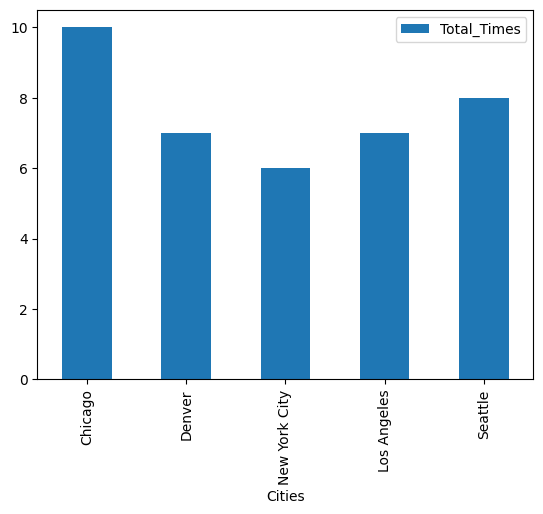

In [24]:
cities_df.plot(
  kind = 'bar',
    x = 'Cities',
    y = 'Total_Times',
) ;

## Problem 7


Drop the 'Total_Times' column from your data frame.

In [29]:
cities_df.drop(
    labels = 'Total_Times',
    axis = 1,
    inplace = True,
)
cities_df

,Cities,States,Region,Times_1,Times_2,Times_3
0,Chicago,Illinois,Midwest,5,2,3
1,Denver,Colorado,West,2,4,1
2,New York City,New York,Northwest,1,3,2
3,Los Angeles,California,West,0,2,5
4,Seattle,Washington,West,3,1,4


## Problem 8


Restructure your data frame using the pandas `.melt()` method. In the `.melt()` method, specify `id_vars = ['Cities', 'States', 'Region']`. Save the melted data frame as a new variable called `cities_df_melted`. Print out `cities_df_melted`.

> Note: make sure to read through the documentation for the `.melt()` method to understand what the method does.

In [32]:
cities_df_melted = cities_df.melt(
  id_vars = ['Cities', 'States','Region'],
  var_name = 'Person',
  value_name = 'Times',
)

cities_df_melted

,Cities,States,Region,Person,Times
0,Chicago,Illinois,Midwest,Times_1,5
1,Denver,Colorado,West,Times_1,2
2,New York City,New York,Northwest,Times_1,1
3,Los Angeles,California,West,Times_1,0
4,Seattle,Washington,West,Times_1,3
5,Chicago,Illinois,Midwest,Times_2,2
6,Denver,Colorado,West,Times_2,4
7,New York City,New York,Northwest,Times_2,3
8,Los Angeles,California,West,Times_2,2
9,Seattle,Washington,West,Times_2,1


## Problem 9


Use the seaborn `barplot()` function to create a barplot of `cities_df_melted` with `Cities` on the x axis, `value` on the y axis and the hue parameter set to `variable`.

In [33]:
import seaborn as sns

In [43]:
sns.barplot(
  x = 'Cities',
  y = ['Times_1','Times_2','Times_3'],
  hue = 'variable',
  data = cities_df_melted
)

ValueError: Length of list vectors must match length of `data` when both are used, but `data` has length 15 and the vector passed to `y` has length 3.